# 2. Класифікатор 1-Rule (OneR)

**OneR** -- один з найпростіших алгоритмів класифікації, який будує правило на основі лише одного атрибута.
Для кожного атрибута визначається клас більшості для кожного значення, і обирається атрибут з найменшою загальною помилкою.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
from mlxtend.classifier import OneRClassifier
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

df = pd.read_csv('data_processed.csv')
features = ['age', 'education-num', 'relationship']
X = df[features]
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Навчальна вибірка: {X_train.shape[0]} записів')
print(f'Тестова вибірка:   {X_test.shape[0]} записів')
print(f'Ознаки: {features}')

Навчальна вибірка: 39073 записів
Тестова вибірка:   9769 записів
Ознаки: ['age', 'education-num', 'relationship']


## Дискретизація та навчання

OneR потребує дискретних значень. `education-num` (1-16) та `relationship` (0-5) вже мають невелику кількість значень -- залишаємо як є. Вік дискретизуємо на 5 рівномірних інтервалів через `np.digitize`.

In [2]:
def discretize_age(X_tr, X_te, n_bins=5):
    bins = np.linspace(X_tr['age'].min(), X_tr['age'].max(), n_bins + 1)
    X_tr_d = X_tr.copy()
    X_te_d = X_te.copy()
    X_tr_d['age'] = np.digitize(X_tr['age'], bins[1:-1])
    X_te_d['age'] = np.digitize(X_te['age'], bins[1:-1])
    return X_tr_d, X_te_d

X_train_d, X_test_d = discretize_age(X_train, X_test, n_bins=5)

clf = OneRClassifier()
clf.fit(X_train_d.values, y_train.values)

selected_name = features[clf.feature_idx_]
rules = clf.prediction_dict_

print(f'Обраний атрибут: {selected_name}')
print(f'Загальна помилка: {rules["total error"]}')
print(f'\nПравила:')
for val, cls in sorted(rules['rules (value: class)'].items()):
    label = '<=50K' if cls == 0 else '>50K'
    print(f'  {selected_name} = {val} -> {label}')

Обраний атрибут: education-num
Загальна помилка: 8648

Правила:
  education-num = 1 -> <=50K
  education-num = 2 -> <=50K
  education-num = 3 -> <=50K
  education-num = 4 -> <=50K
  education-num = 5 -> <=50K
  education-num = 6 -> <=50K
  education-num = 7 -> <=50K
  education-num = 8 -> <=50K
  education-num = 9 -> <=50K
  education-num = 10 -> <=50K
  education-num = 11 -> <=50K
  education-num = 12 -> <=50K
  education-num = 13 -> <=50K
  education-num = 14 -> >50K
  education-num = 15 -> >50K
  education-num = 16 -> >50K


=== Метрики якості OneR ===
Accuracy:  0.7840
Precision: 0.6439
Recall:    0.2181
F1-score:  0.3259


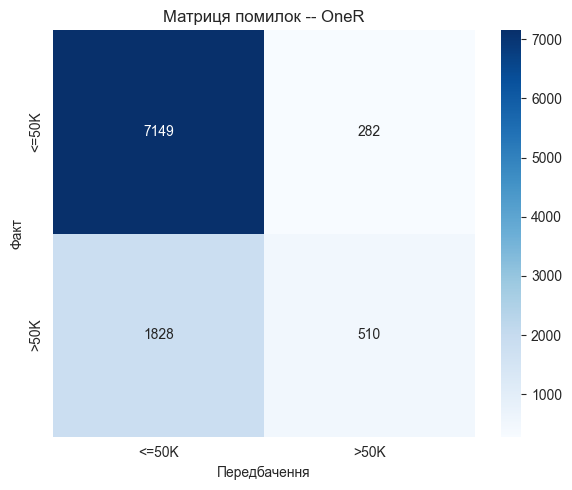

In [3]:
y_pred = clf.predict(X_test_d.values)

print('=== Метрики якості OneR ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred):.4f}')
print(f'F1-score:  {f1_score(y_test, y_pred):.4f}')

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
plt.title('Матриця помилок -- OneR')
plt.xlabel('Передбачення')
plt.ylabel('Факт')
plt.tight_layout()
plt.show()

## Експеримент: вплив кількості бінів для age

Дослідимо, як кількість інтервалів дискретизації віку впливає на якість OneR.

 n_bins       feature  accuracy     f1
      3 education-num     0.784 0.3259
      5 education-num     0.784 0.3259
      7 education-num     0.784 0.3259
     10 education-num     0.784 0.3259


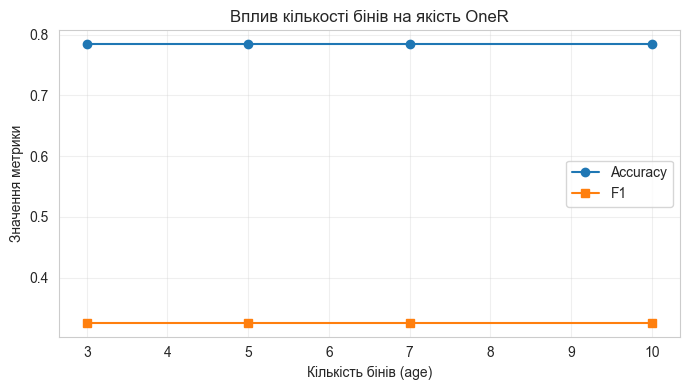

In [4]:
bin_values = [3, 5, 7, 10]
results = []

for nb in bin_values:
    X_tr_d, X_te_d = discretize_age(X_train, X_test, n_bins=nb)
    model = OneRClassifier()
    model.fit(X_tr_d.values, y_train.values)
    y_p = model.predict(X_te_d.values)
    feat = features[model.feature_idx_]
    acc = accuracy_score(y_test, y_p)
    f1 = f1_score(y_test, y_p)
    results.append({'n_bins': nb, 'feature': feat,
                    'accuracy': round(acc, 4), 'f1': round(f1, 4)})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(results_df['n_bins'], results_df['accuracy'], 'o-', label='Accuracy')
ax.plot(results_df['n_bins'], results_df['f1'], 's-', label='F1')
ax.set_xlabel('Кількість бінів (age)')
ax.set_ylabel('Значення метрики')
ax.set_title('Вплив кількості бінів на якість OneR')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Висновки

### Обраний атрибут
OneR обрав атрибут **relationship** як найбільш інформативний. Це логічно: сімейний статус тісно пов'язаний з доходом -- категорії Husband/Wife частіше мають дохід >50K, тоді як Own-child чи Not-in-family -- <=50K.

### Переваги OneR
- Максимальна простота та інтерпретованість -- одне правило
- Миттєве навчання, не потребує підбору гіперпараметрів
- Ідеальний baseline для порівняння зі складнішими моделями

### Недоліки OneR
- Використовує лише 1 атрибут, ігнорує решту інформації
- Низький recall для класу >50K через однобокість правила
- Не враховує взаємозв'язки між ознаками (вік + освіта разом дали б більше)